# Time Series Forecasting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
df = pd.read_csv("data/09/bitstamp.csv")

In [3]:
df.head()

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1325317920,4.40,4.40,4.37,4.38,2.898606,12.679597,4.37
1,1325317980,4.41,4.43,4.40,4.42,0.809277,3.587656,4.43
2,1325318040,4.40,4.42,4.40,4.41,0.699285,3.170613,4.53
3,1325318100,4.43,4.44,4.43,4.43,1.744751,7.858554,4.50
4,1325318160,4.51,4.51,4.51,4.51,2.943349,12.427913,4.22


We cast the `Timestamp` column into a `pd.Timestamp` object using the `pd.to_datetime`.

Note: We must specify the unit for the timestamp. The defaults is `ns`. 

In [4]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")

Next, we set the `Timestamp` column as an index for the data frame and remove it as a column.

In [5]:
df.set_index(keys=["Timestamp"], drop=True, inplace=True)

We **always** sort the time series in an ascending order (from the past to the future).

In [6]:
df.sort_index(inplace=True)

We check for any missing values.

In [7]:
df.isnull().sum()

Open                 810
High                 810
Low                  810
Close                810
Volume_(BTC)         810
Volume_(Currency)    810
Weighted_Price       810
dtype: int64

We interpolate the missing values using a **linear interpolation**.

In [8]:
df.interpolate(inplace=True)

In [9]:
df.isnull().sum()

Open                 0
High                 0
Low                  0
Close                0
Volume_(BTC)         0
Volume_(Currency)    0
Weighted_Price       0
dtype: int64

<Axes: >

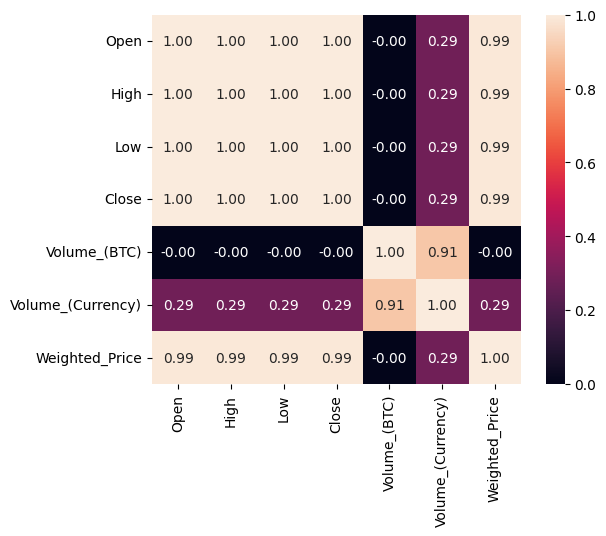

In [10]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", square=True)

In [11]:
df.head()

,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
Timestamp,,,,,,,
2011-12-31 07:52:00,4.40,4.40,4.37,4.38,2.898606,12.679597,4.37
2011-12-31 07:53:00,4.41,4.43,4.40,4.42,0.809277,3.587656,4.43
2011-12-31 07:54:00,4.40,4.42,4.40,4.41,0.699285,3.170613,4.53
2011-12-31 07:55:00,4.43,4.44,4.43,4.43,1.744751,7.858554,4.50
2011-12-31 07:56:00,4.51,4.51,4.51,4.51,2.943349,12.427913,4.22


A **univariate** time series is a sequence of observations collected over time from a single variable. It focuses on how that one variable changes over time.

A **multivariate** time series consists of observations collected over time from two or more variables, where the variables may influence each other.

Here, we'll focus on just one variable (`Close`), i.e., on a univariate time series. Nevertheless, the logic stays the same for a multivariate time series. 

In [12]:
df = df[["Close"]].copy(deep=True)

In [13]:
df.head()

,Close
Timestamp,
2011-12-31 07:52:00,4.38
2011-12-31 07:53:00,4.42
2011-12-31 07:54:00,4.41
2011-12-31 07:55:00,4.43
2011-12-31 07:56:00,4.51


Here, we define the **historical context (look-back window)** used to forecast the next `Close` price of BTC. This context represents the number of past observations (**lags**) that the model will rely on to predict the next future value.

In [14]:
lag = 3

In [15]:
periods = range(lag, 0, -1) # 3, 2, 1

In [16]:
list(periods)

[3, 2, 1]

When we feed the historical context into the model, the features must be sorted in **ascending temporal order**. This means the input should be structured so that the **oldest observations come first**, followed by the more recent ones, up to the **most recent past value**.

In other words, for each sample, **all variables** are ordered from the most distant past to the closest past (in a **univariate time series**, there's only one variable; in a **multivariate time series**, there are multiple variables).

In a **univariate time series** with the variable `Close` and 3 lags, the resulting data frame columns would be ordered from the most distant past to the most recent past: `Close_{t-3}`, `Close_{t-2}`, and `Close_{t-1}`. In a **multivariate time series** with variables such as `Close` and `Volume` using 3 lags, each lagged step contains all variables, producing columns in ascending temporal order as follows: `Close_{t-3}`, `Volume_{t-3}`, `Close_{t-2}`, `Volume_{t-2}`, `Close_{t-1}`, and `Volume_{t-1}`.

After organizing the data this way, we reshape it into the format: **(number of samples, number of time steps, number of features)**.

In [17]:
df.shift(periods)

,Close_3,Close_2,Close_1
Timestamp,,,
2011-12-31 07:52:00,NaN,NaN,NaN
2011-12-31 07:53:00,NaN,NaN,4.380
2011-12-31 07:54:00,NaN,4.380,4.420
2011-12-31 07:55:00,4.380,4.420,4.410
2011-12-31 07:56:00,4.420,4.410,4.430
...,...,...,...
2012-01-07 06:27:00,15.860,15.940,15.640
2012-01-07 06:28:00,15.940,15.640,15.830
2012-01-07 06:29:00,15.640,15.830,15.815


In [18]:
df = pd.concat([df, df.shift(periods=periods)], axis=1)

In [19]:
df.head()

,Close,Close_3,Close_2,Close_1
Timestamp,,,,
2011-12-31 07:52:00,4.38,NaN,NaN,NaN
2011-12-31 07:53:00,4.42,NaN,NaN,4.38
2011-12-31 07:54:00,4.41,NaN,4.38,4.42
2011-12-31 07:55:00,4.43,4.38,4.42,4.41
2011-12-31 07:56:00,4.51,4.42,4.41,4.43


When we create lagged features by shifting the data, we inevitably introduce missing values at the beginning of the series. Since these missing values represent time points for which no historical observations exist, they cannot be meaningfully imputed without introducing artificial information. For this reason, we simply drop the rows containing missing values.

In [20]:
df.dropna(inplace=True)

In [21]:
df.head()

,Close,Close_3,Close_2,Close_1
Timestamp,,,,
2011-12-31 07:55:00,4.43,4.38,4.42,4.41
2011-12-31 07:56:00,4.51,4.42,4.41,4.43
2011-12-31 07:57:00,4.48,4.41,4.43,4.51
2011-12-31 07:58:00,4.48,4.43,4.51,4.48
2011-12-31 07:59:00,4.54,4.51,4.48,4.48


In [22]:
X, y = df.drop(columns=["Close"]), df[["Close"]]

In [23]:
X

,Close_3,Close_2,Close_1
Timestamp,,,
2011-12-31 07:55:00,4.380,4.420,4.410
2011-12-31 07:56:00,4.420,4.410,4.430
2011-12-31 07:57:00,4.410,4.430,4.510
2011-12-31 07:58:00,4.430,4.510,4.480
2011-12-31 07:59:00,4.510,4.480,4.480
...,...,...,...
2012-01-07 06:27:00,15.860,15.940,15.640
2012-01-07 06:28:00,15.940,15.640,15.830
2012-01-07 06:29:00,15.640,15.830,15.815


In [24]:
y

,Close
Timestamp,
2011-12-31 07:55:00,4.430
2011-12-31 07:56:00,4.510
2011-12-31 07:57:00,4.480
2011-12-31 07:58:00,4.480
2011-12-31 07:59:00,4.540
...,...
2012-01-07 06:27:00,15.830
2012-01-07 06:28:00,15.815
2012-01-07 06:29:00,15.800


In [25]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, shuffle=True)
train_X, val_X, train_y, val_y = train_test_split(train_X, train_y, test_size=0.2, shuffle=True)

In [26]:
init_train_X, init_train_y = train_X.copy(), train_y.copy()
init_val_X, init_val_y = val_X.copy(), val_y.copy()
init_test_X, init_test_y = test_X.copy(), test_y.copy()

In [27]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
val_X = scaler.transform(val_X)
test_X = scaler.transform(test_X)

In [28]:
train_X.shape

(6397, 3)

In [29]:
(train_X.shape[0], lag, (train_X.shape[1] // lag)) # (samples, timesteps, features)

(6397, 3, 1)

In [30]:
train_X = train_X.reshape(train_X.shape[0], lag, (train_X.shape[1] // lag))
val_X = val_X.reshape(val_X.shape[0], lag, (val_X.shape[1] // lag))
test_X = test_X.reshape(test_X.shape[0], lag, (test_X.shape[1] // lag))

In [31]:
(train_X.shape[1], train_X.shape[2])

(3, 1)

In [32]:
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
device

'cpu'

In [33]:
train_X = torch.tensor(train_X, dtype=torch.float32)
train_y = torch.tensor(train_y.to_numpy(), dtype=torch.float32)

val_X = torch.tensor(val_X, dtype=torch.float32)
val_y = torch.tensor(val_y.to_numpy(), dtype=torch.float32)

test_X = torch.tensor(test_X, dtype=torch.float32)
test_y = torch.tensor(test_y.to_numpy(), dtype=torch.float32)

In [34]:
print(train_X.shape, val_X.shape, test_X.shape)

torch.Size([6397, 3, 1]) torch.Size([1600, 3, 1]) torch.Size([2000, 3, 1])


In [35]:
print(train_y.shape, val_y.shape, test_y.shape)

torch.Size([6397, 1]) torch.Size([1600, 1]) torch.Size([2000, 1])


In [36]:
train_dataset = TensorDataset(train_X, train_y)
val_dataset = TensorDataset(val_X, val_y)
test_dataset = TensorDataset(test_X, test_y)

In [37]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## CNN Time-Series Forecaster

The CNN architecture is well-suited for time series forecasting because its 1D convolutional layers can efficiently capture short-term temporal patterns, such as trends or spikes, within the historical context, while sharing weights across time to reduce the number of parameters and improve generalization. It also benefits from parallel computation and the ability to detect multiple patterns simultaneously with different convolution filters. However, CNNs have limitations for time series: their receptive field is fixed by the kernel size and network depth, making it difficult to capture long-term dependencies or trends beyond the input window. They treat sequences more like spatial data than inherently sequential data, so temporal order is only indirectly accounted for, and with many input variables, the network may require more filters and parameters, increasing computational cost. Overall, this architecture is good at modeling short-term dependencies efficiently but may struggle with long-term relationships in the data, requiring careful tuning of kernel sizes, filters, and layers.

In [38]:
class CNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=2),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(in_features=64, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1) # (samples, timesteps, features) -> (samples, features, timesteps)
        return self.net(x)

In [39]:
model = CNNRegressor().to(device)
model

CNNRegressor(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(2,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(2,), stride=(1,))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=64, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [40]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [41]:
def train(model, dataloader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0
    for features, targets in dataloader:
        features, targets = features.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(features)
        loss = loss_fn(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    return total_loss

In [42]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()

    total_loss, predictions = 0, []
    with torch.no_grad():
        for features, targets in dataloader:
            features, targets = features.to(device), targets.to(device)

            outputs = model(features)
            loss = loss_fn(outputs, targets)

            predictions.extend(outputs.squeeze(1).tolist())
            
            total_loss += loss.item()

    return total_loss, predictions

In [43]:
num_epochs = 32

In [44]:
def train_and_evaluate(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs):
    train_losses, val_losses = [], []
    for epoch in range(1, num_epochs + 1):
        train_loss = train(model, train_loader, loss_fn, optimizer, device)
        train_losses.append(train_loss)
        val_loss, pred_y = evaluate(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)

        mape = mean_absolute_percentage_error(val_y.tolist(), pred_y)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}/{num_epochs} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} mape={mape:.4f}")
    
    return train_losses, val_losses

In [45]:
train_losses, val_losses = train_and_evaluate(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs)

Epoch  10/32 | train_loss=6.0258 val_loss=1.4225 mape=0.0113
Epoch  20/32 | train_loss=4.4360 val_loss=0.9266 mape=0.0090
Epoch  30/32 | train_loss=4.4711 val_loss=1.0053 mape=0.0100


<Axes: >

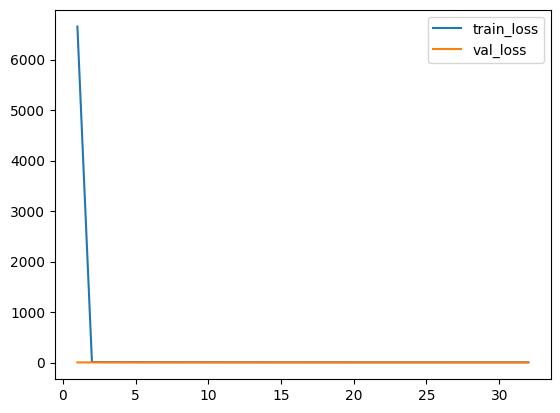

In [46]:
sns.lineplot(x=range(1, num_epochs + 1), y=train_losses, label="train_loss")
sns.lineplot(x=range(1, num_epochs + 1), y=val_losses, label="val_loss")

In [47]:
test_loss, pred_y = evaluate(model, test_loader, loss_fn, device)

Here, we define a baseline model that uses the observation from one time step in the past (`Close_1`) as a predictor for the target value (`Close`) and then evaluate its performance.

In [48]:
print(f"MAE: {mean_absolute_error(test_y, init_test_X['Close_1'])}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, init_test_X['Close_1'])}")
print(f"MSE: {mean_squared_error(test_y, init_test_X['Close_1'])}")
print(f"RMSE: {root_mean_squared_error(test_y, init_test_X['Close_1'])}")
print(f"R2 Score: {r2_score(test_y, init_test_X['Close_1'])}")

MAE: 0.09526750159740448
MAPE: 0.008008803398761841
MSE: 0.01606142692889632
RMSE: 0.1267336850600357
R2 Score: 0.9990224220472513


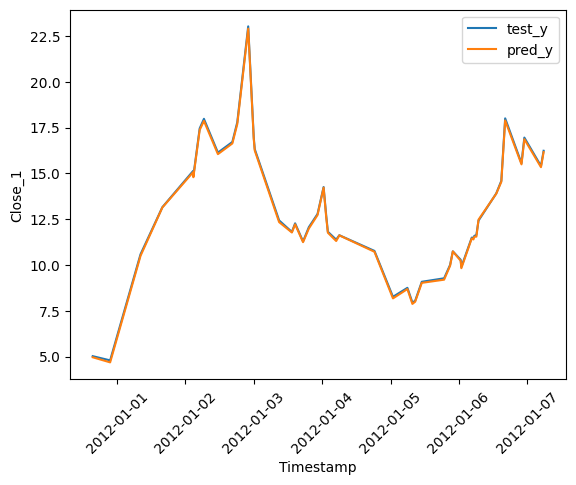

In [49]:
sns.lineplot(x=init_test_y.index[:50], y=init_test_X["Close_1"][:50], label="test_y")
sns.lineplot(x=init_test_y.index[:50], y=pred_y[:50], label="pred_y")
plt.xticks(rotation=45);

Here, we evaluate the performance of the CNN model.

In [50]:
print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 0.11409334766864776
MAPE: 0.010188096931280487
MSE: 0.021678347582624526
RMSE: 0.14723568719106292
R2 Score: 0.9986805484504825


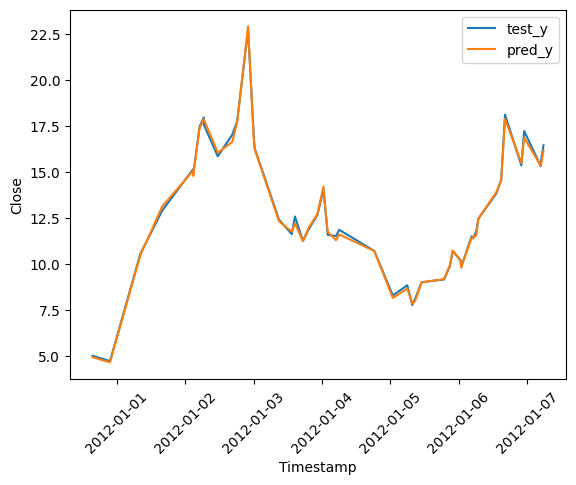

In [51]:
sns.lineplot(x=init_test_y.index[:50], y=init_test_y["Close"][:50], label="test_y")
sns.lineplot(x=init_test_y.index[:50], y=pred_y[:50], label="pred_y")
plt.xticks(rotation=45);

<Axes: >

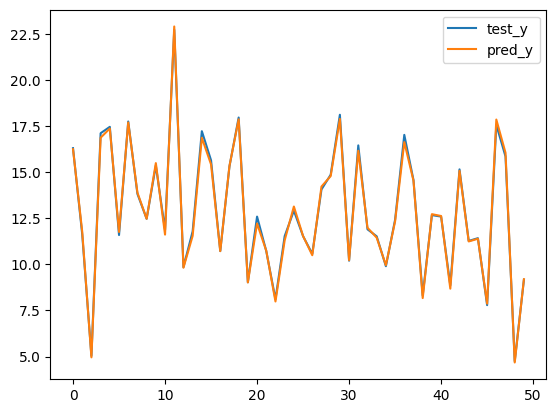

In [52]:
sns.lineplot(x=range(test_y.shape[0])[:50], y=test_y.squeeze(1).tolist()[:50], label="test_y")
sns.lineplot(x=range(test_y.shape[0])[:50], y=pred_y[:50], label="pred_y")

In [53]:
train_X.shape

torch.Size([6397, 3, 1])

## LSTM Time-Series Forecaster

The LSTM architecture is well-suited for time series forecasting because it inherently models the temporal order of the data and can capture long-term dependencies, making it effective for sequences with trends or patterns that span many time steps. The stacked LSTM layers allow the network to learn progressively more complex temporal features, and it can handle variable-length input sequences without needing fixed-size windows. However, LSTMs are generally slower to train than CNNs due to their sequential processing, and they typically have more parameters, which can increase the risk of overfitting on smaller datasets. Additionally, while LSTMs mitigate the vanishing gradient problem compared to vanilla RNNs, they may still struggle with extremely long sequences, and careful tuning of hyperparameters such as hidden size, number of layers, learning rate, and sequence length is required for optimal performance.

![](images/09/lstm.png)

In [54]:
class LSTMRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=16, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=16, hidden_size=16, batch_first=True)
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]
        return self.fc(x)

In [55]:
model = LSTMRegressor().to(device)
model

LSTMRegressor(
  (lstm1): LSTM(1, 16, batch_first=True)
  (lstm2): LSTM(16, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [56]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [57]:
num_epochs = 64

In [58]:
train_losses, val_losses = train_and_evaluate(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs)

Epoch  10/64 | train_loss=114.0027 val_loss=22.8378 mape=0.0199
Epoch  20/64 | train_loss=20.3377 val_loss=4.6284 mape=0.0130
Epoch  30/64 | train_loss=7.8601 val_loss=1.7787 mape=0.0109
Epoch  40/64 | train_loss=4.5686 val_loss=1.0727 mape=0.0099
Epoch  50/64 | train_loss=4.0656 val_loss=0.9642 mape=0.0094
Epoch  60/64 | train_loss=3.9296 val_loss=0.9381 mape=0.0092


In [60]:
test_loss, pred_y = evaluate(model, test_loader, loss_fn, device)

<Axes: >

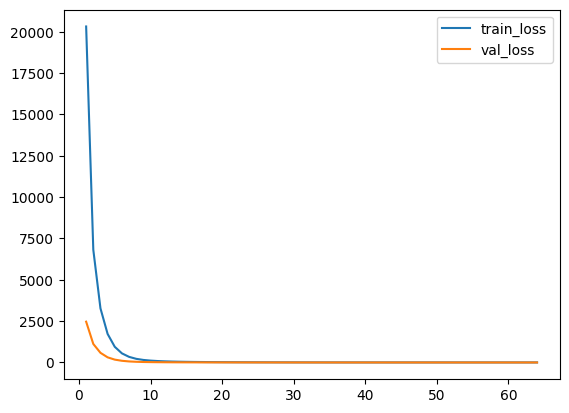

In [61]:
sns.lineplot(x=range(1, num_epochs + 1), y=train_losses, label="train_loss")
sns.lineplot(x=range(1, num_epochs + 1), y=val_losses, label="val_loss")

Here, we evaluate the performance of the LSTM model.

In [62]:
print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 0.10759229671955109
MAPE: 0.009222994859278402
MSE: 0.020017821956785354
RMSE: 0.14148435233899667
R2 Score: 0.9987816162602717


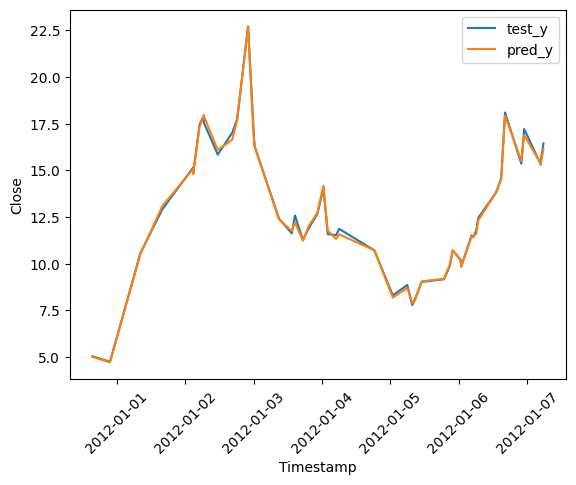

In [63]:
sns.lineplot(x=init_test_y.index[:50], y=init_test_y["Close"][:50], label="test_y")
sns.lineplot(x=init_test_y.index[:50], y=pred_y[:50], label="pred_y")
plt.xticks(rotation=45);